# 01 Exploratory Data Analysis

**Purpose:** Understand the structure, quality, and statistical properties of both series before any modelling. Every modelling decision in `02_modelling.ipynb` should trace back to a finding in this notebook.

**Datasets loaded from `data/processed/`:**
- `pjm_hourly_energy_consumption.parquet` — hourly MWh consumption, PJM grid, 2002–2018
- `ice_electric_prices.parquet` — daily wholesale spot price ($/MWh) at PJM West hub, 2001–2018

**End goal:** A 12-month ahead price forecast with prediction intervals to support CFO energy-cost budgeting.

## 0 · Setup

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL
from scipy import stats

# Change working directory to repo root (notebook is in notebooks/ subfolder)
os.chdir("..")

---
## 1 · Data Validation

**Question:** Are both datasets complete, correctly typed, and covering the expected date range, or do they contain gaps, type mismatches, or truncation that must be resolved before analysis?

**Exit criterion:** Both DataFrames have a confirmed datetime index with the correct frequency, no unexpected dtypes, and known missing-value counts are documented. Date ranges are consistent with source documentation. No further data-quality surprises should emerge later in the notebook.

In [3]:
# Load both datasets from data/processed/
df_pjm_hourly_consumption = pd.read_parquet("data/processed/pjm_hourly_energy_consumption.parquet")
df_ice_electric_prices = pd.read_parquet("data/processed/ice_electric_prices.parquet")

---
**NOTE:** Holdout evaluation.   

So we can test whether the ultimate model holds up under conditions that resemble practice, we will remove the last year of data from `df_pjm_hourly_consumption`. We will revisit this data again in `03_holdout_evaluation.ipynb`.

To do this we will find the maximum datetime value in `df_pjm_hourly_consumption` index and subtract one year to get the cutoff date for filtering df_ice_electric_prices.

In [4]:
# Start from the last complete month in the dataset
last_complete_month_end = (df_pjm_hourly_consumption.index.max().to_period('M') - 1).to_timestamp('M')

# Subtract one year to define the holdout boundary
holdout_boundary = last_complete_month_end - pd.DateOffset(years=1)

# Add one day to move from end of month to start of the following month
HOLDOUT_START = holdout_boundary + pd.DateOffset(days=1)

# Finally, we will filter the datasets.
df_pjm_hourly_consumption = df_pjm_hourly_consumption[df_pjm_hourly_consumption.index < HOLDOUT_START]
df_ice_electric_prices = df_ice_electric_prices[df_ice_electric_prices["trade_date"] < HOLDOUT_START]

---
Data Validation continued...

### PJM hourly consumption

In [5]:
df_pjm_hourly_consumption.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 134397 entries, 2002-04-01 01:00:00 to 2017-07-31 23:00:00
Data columns (total 1 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   consumption_mw  134397 non-null  float32
dtypes: float32(1)
memory usage: 1.5 MB


Let's check for gaps in the hourly consumption time series.

In [6]:
# Detect gaps
gaps = df_pjm_hourly_consumption[df_pjm_hourly_consumption.index.to_series().diff() > pd.Timedelta(days=1)]
print(f"Gaps found: {len(gaps)}")
print(gaps)

Gaps found: 0
Empty DataFrame
Columns: [consumption_mw]
Index: []


There are no gaps, so there is no need for any kind of imputation.

Let's now down-sample to a daily energy usage. We will do this by summing the megawatt (MW) consumption daily, which will produce a unit of megawatt-hour.

In [7]:
df_pjm_daily_consumption = df_pjm_hourly_consumption.copy()

df_pjm_daily_consumption = df_pjm_daily_consumption['consumption_mw'].resample('D').sum()

# renaming a series
df_pjm_daily_consumption.name = "consumption_mwh"

We now have a clean daily consumption time series.

### ICE electric prices

In [8]:
# Only keep columns from df_ice_electric_prices that will be used in modeling
df_ice_electric_prices = df_ice_electric_prices[["trade_date", "wtd_avg_price_mwh"]]

In [9]:
df_ice_electric_prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   trade_date         4225 non-null   datetime64[ns]
 1   wtd_avg_price_mwh  4225 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 66.1 KB


In [10]:
# Do any rows have duplicate trade_dates?
duplicate_trade_dates = df_ice_electric_prices[df_ice_electric_prices.duplicated(subset=["trade_date"], keep=False)]
print(duplicate_trade_dates)

     trade_date  wtd_avg_price_mwh
3405 2014-05-12              63.15
3406 2014-05-12              63.15
3647 2015-04-28              34.97
3648 2015-04-28              34.97
3820 2015-12-31              41.70
3821 2015-12-31              41.70
3822 2016-01-04              43.06
3823 2016-01-04              43.06
3824 2016-01-05              36.76
3825 2016-01-05              36.76
3832 2016-01-15              24.19
3833 2016-01-15              46.11
3845 2016-02-03              23.57
3846 2016-02-03              25.62
4078 2017-01-03              34.39
4079 2017-01-03              34.39


There are two types of duplicate trade dates in this dataset. In the first type the weighted average price is identical across both rows, indicating the same record appears twice. These are removed without consequence.

In the second type the prices differ. There are two instances of this out of 4582 rows. Rather than averaging or discarding arbitrarily, we retain the higher of the two prices. From a budgeting perspective this is the more conservative assumption: if the true market price for that day is uncertain, the CFO is better protected by planning for the higher figure than by underestimating cost. 

In [11]:
df_ice_electric_prices = (
    df_ice_electric_prices
    .groupby("trade_date")["wtd_avg_price_mwh"]
    .max()
    .reset_index()
    .set_index("trade_date")
)

Now let's check for gaps in the time series.

In [12]:
# Detect gaps
gaps = df_ice_electric_prices[df_ice_electric_prices.index.to_series().diff() > pd.Timedelta(days=1)]
print(f"Gaps found: {len(gaps)}")
print(gaps)

Gaps found: 907
            wtd_avg_price_mwh
trade_date                   
2001-01-08              59.50
2001-01-15              44.21
2001-01-22              50.50
2001-01-29              35.57
2001-02-05              36.94
...                       ...
2017-07-05              30.76
2017-07-10              37.29
2017-07-17              36.10
2017-07-24              28.97
2017-07-31              35.21

[907 rows x 1 columns]


There are many gaps. The assumption is that these gaps missing not at random (MNAR), because there was no trading on the missing dates, where the missing date represent weekends and holidays.

We will therefore use a fill-forward imputation method for filling in the gaps. This thereby assumes that the prices remained the same over weekends.

In [13]:
# Reindex to a complete date range to make gaps explicit
full_index = pd.date_range(
    start=df_ice_electric_prices.index.min(),
    end=df_ice_electric_prices.index.max(),
    freq='D'
)

df_ice_electric_prices = df_ice_electric_prices.reindex(full_index)

df_ice_electric_prices = df_ice_electric_prices.ffill()

In [14]:
# Detect gaps
gaps = df_ice_electric_prices[df_ice_electric_prices.index.to_series().diff() > pd.Timedelta(days=1)]
print(f"Gaps found: {len(gaps)}")
print(gaps)

Gaps found: 0
Empty DataFrame
Columns: [wtd_avg_price_mwh]
Index: []


---
## 2 · Univariate Analysis — Price Series

**Question:** What are the dominant trend, seasonal patterns (annual, monthly, day-of-week), and distributional characteristics of the daily wholesale price series? Are there structural breaks or non-stationarity that will constrain model choice?

**Exit criterion:** Trend direction and approximate magnitude are documented; seasonal strength is quantified at each frequency; distributional shape (skew, heavy tails, zero/negative prices) is characterised; a stationarity assessment (ADF or KPSS) is recorded. The analyst can state whether the series should be modelled in levels, log-levels, or first-differences.

We'll start by plotting the data cross-sectionally and longitudinally.

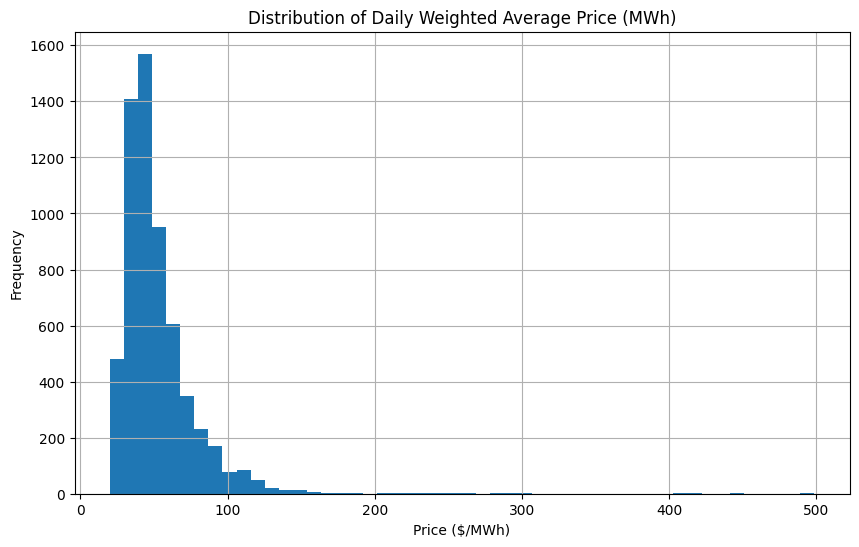

In [19]:
# historgram of prices
df_ice_electric_prices['wtd_avg_price_mwh'].hist(bins=50, figsize=(10, 6))
plt.title('Distribution of Daily Weighted Average Price (MWh)')
plt.xlabel('Price ($/MWh)')
plt.ylabel('Frequency')
plt.show()

Text(0, 0.5, 'Price ($/MWh)')

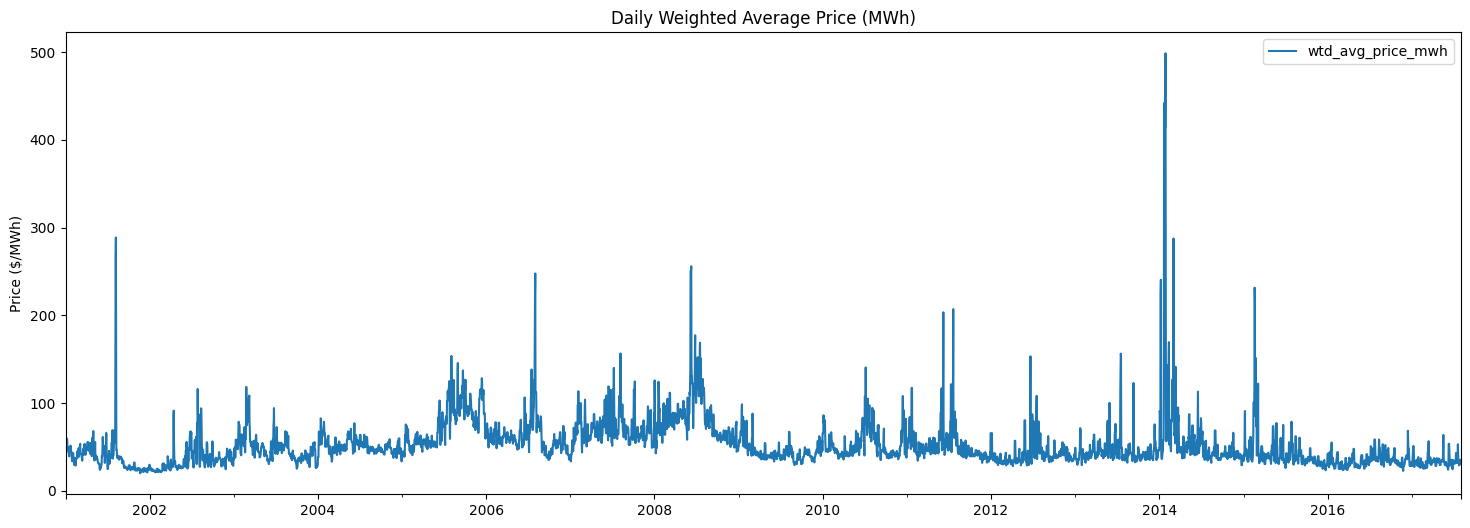

In [39]:
ax = df_ice_electric_prices.plot(
    y="wtd_avg_price_mwh",
    title="Daily Weighted Average Price (MWh)",
    figsize=(18, 6)
)
ax.set_ylabel("Price ($/MWh)")

The plots show a right skewed distribution and a change in variance over time, with some interesting spikes in the price, with the most notable occurring in early 2014.

This peak in January 2014 was due to extremely cold weather as a result of a [polar vortex](https://www.eia.gov/todayinenergy/detail.php?id=14671).

This peak consequentially dominates the plot, making it difficult to visualise the nuances of the time series. We will therefore plot the y-axis on a log scale below.

Text(0, 0.5, 'Price ($/MWh) Log Scaled')

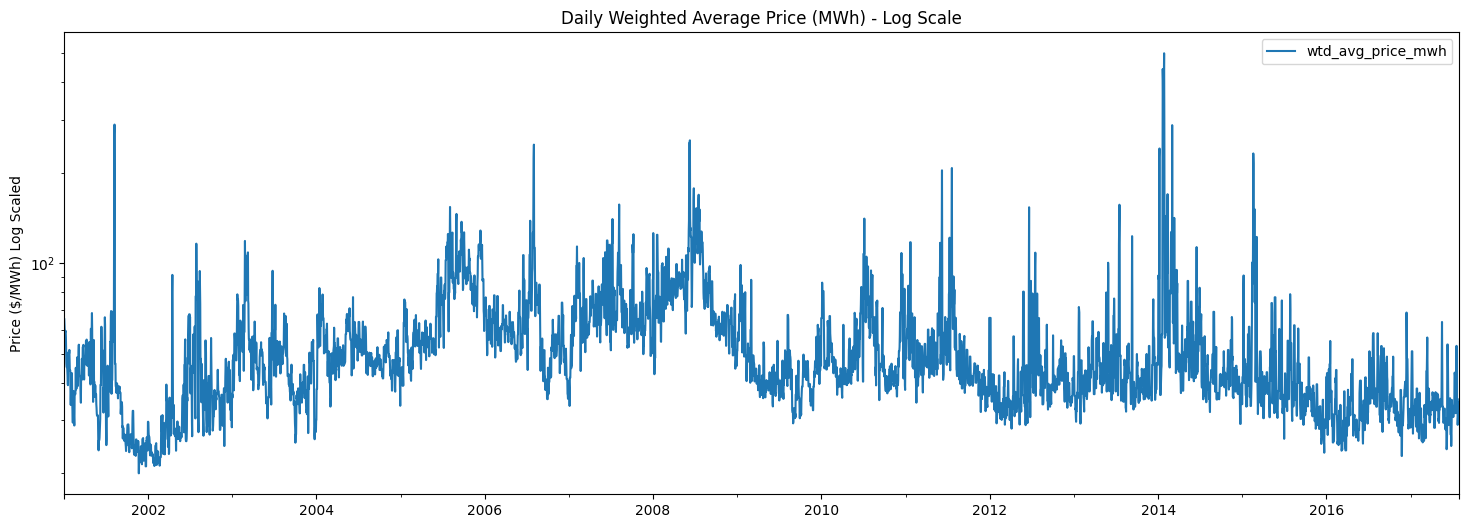

In [20]:
ax = df_ice_electric_prices.plot(
    y="wtd_avg_price_mwh",
    title="Daily Weighted Average Price (MWh) - Log Scale",
    figsize=(18, 6)
)
ax.set_yscale("log")
ax.set_ylabel("Price ($/MWh) Log Scaled")

The plotted series now reveals some seasonality, peaks at interesting events such as the 2008 financial crash, and non-constant variance in the series over time.

To understand these components better, we'll decompose the time series. We'll consider multiple seasonality with periods of 7 and 365, representing weekly and annual periods, which are typical seasonalities for electricity usage.

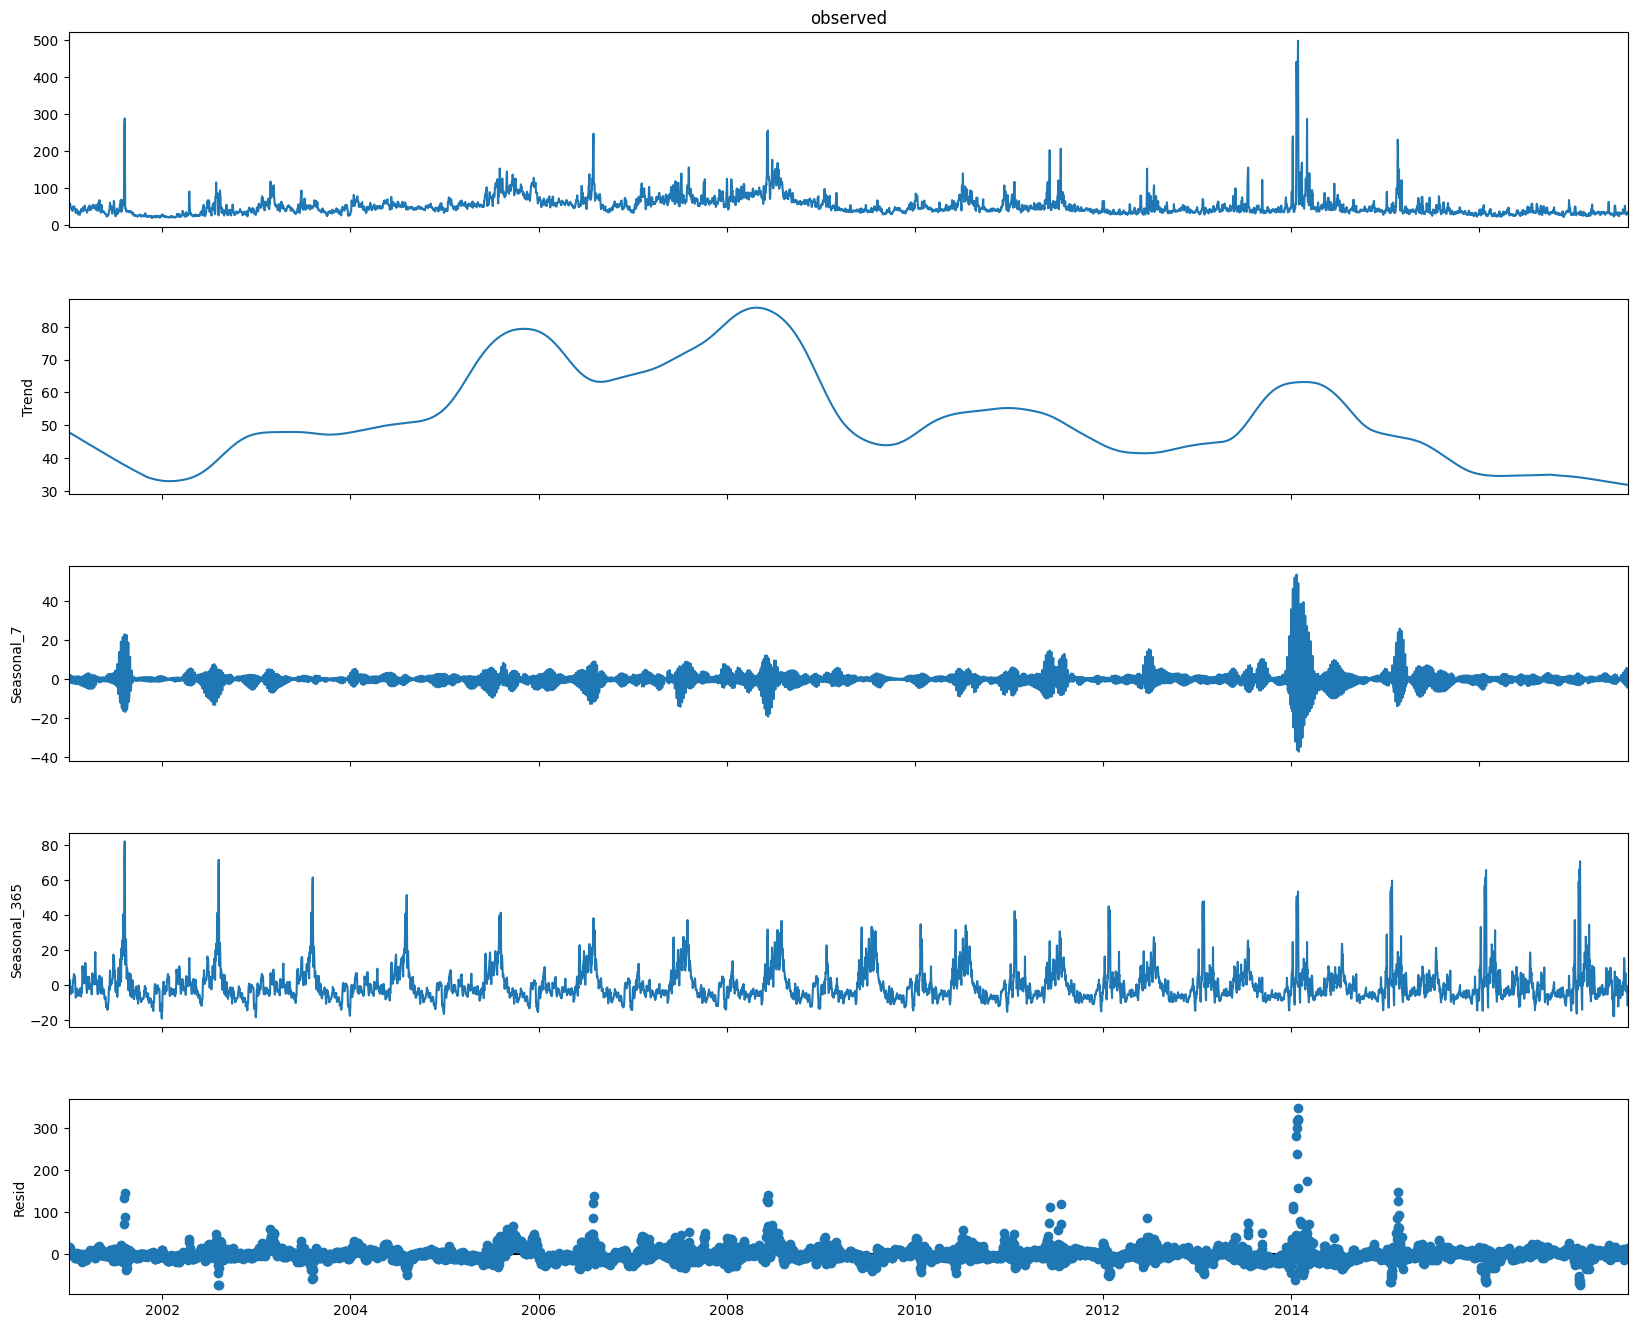

In [32]:
# Time series decomposition - not on log scale
stl = MSTL(df_ice_electric_prices['wtd_avg_price_mwh'], periods=[7,365])
result = stl.fit()

fig = result.plot()
fig.set_size_inches(18, 15)

The seasonal components show a change in variance over time, such as in the 365 period. This is most obvious in the decreasing and increasing size of two sets of respective peaks.

This suggests that the decomposition is multiplicative in nature, instead of additive. This is something that can be accounted for when modelling, by using a boxcox transformation.

For now, we will decompose the series again, but on log transformed data, which is the equivalent of decomposing a multiplicative model. More to the point, we will log transform for the sake of visualisation and for understanding the data better. We will consider boxcox transformation during modelling.

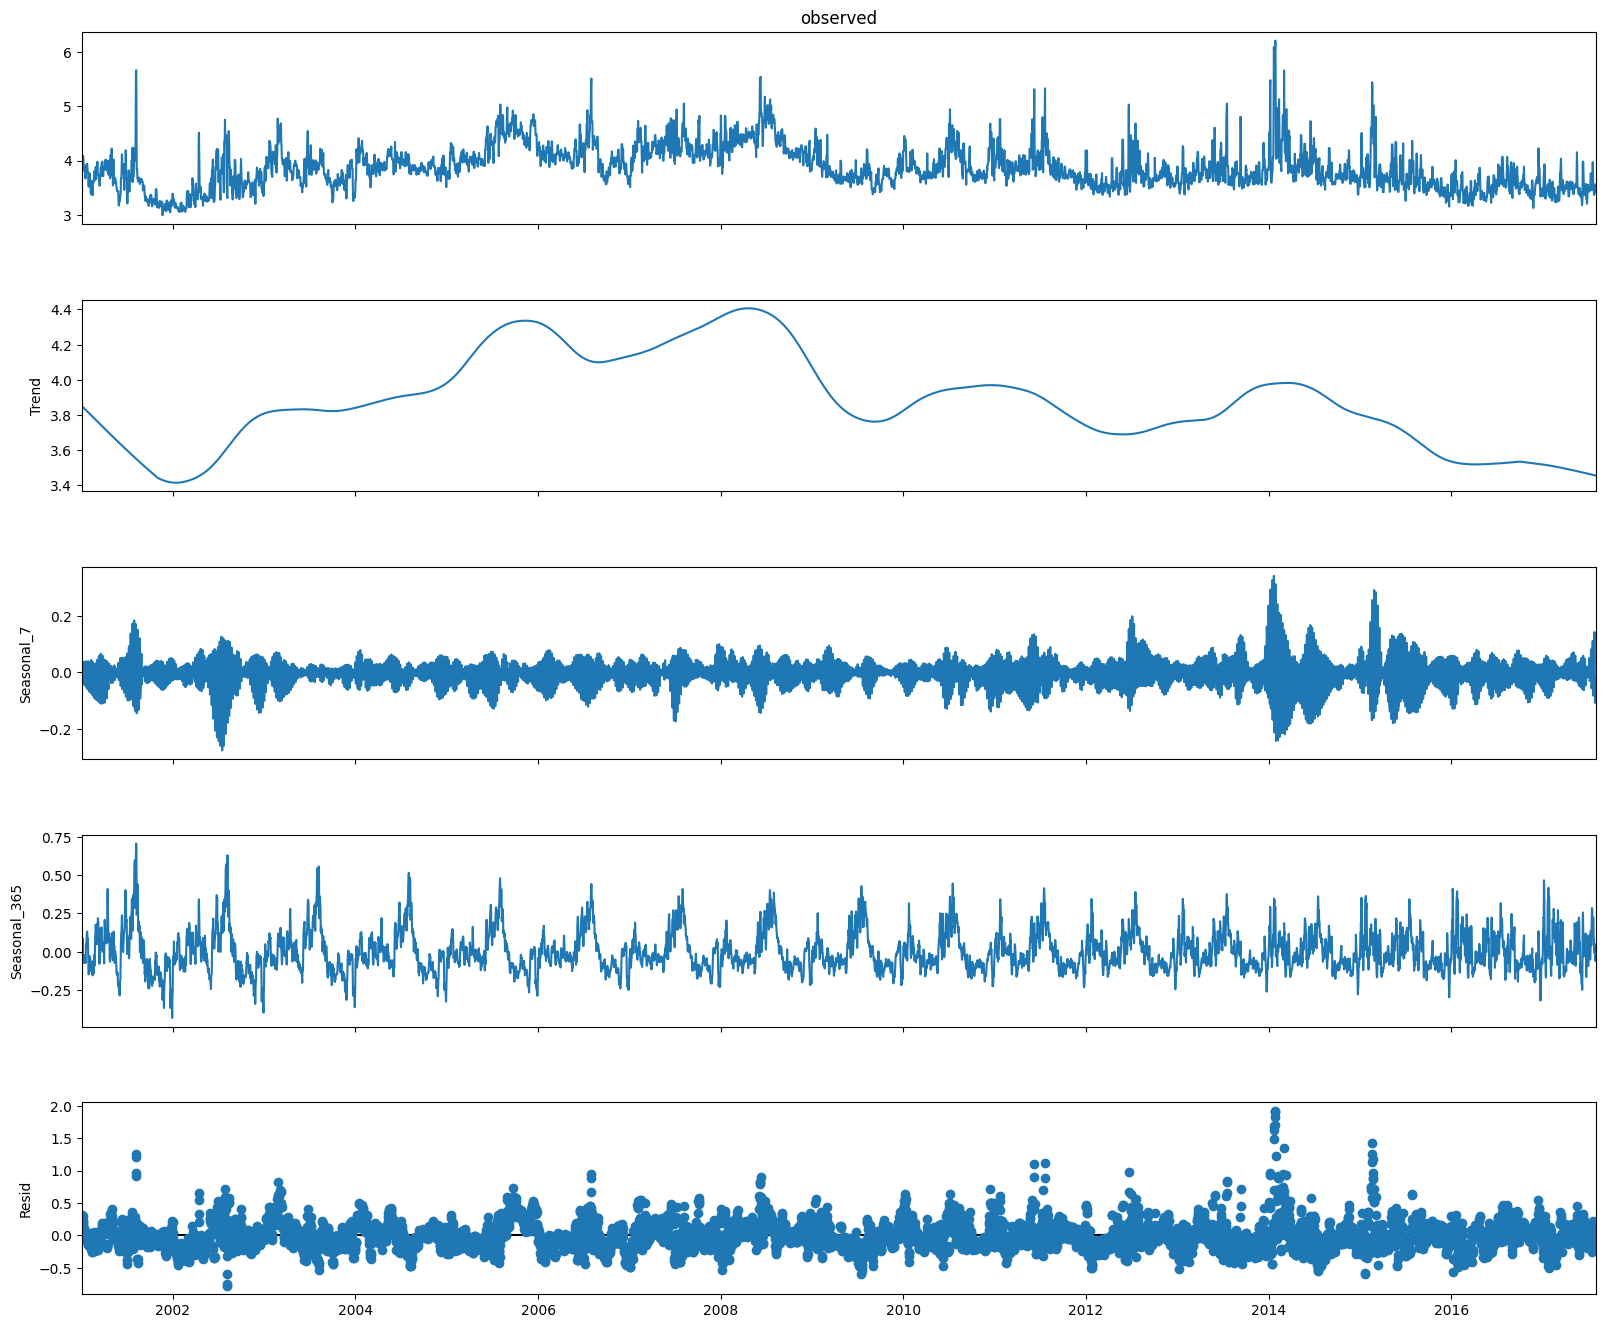

In [34]:
# Annual trend: rolling annual mean/median overlaid on raw series
log_prices = np.log(df_ice_electric_prices['wtd_avg_price_mwh'])

stl = MSTL(log_prices, periods=[7,365])
result = stl.fit()

fig = result.plot()
fig.set_size_inches(18, 15)

The log transformation has tamed the second set of the two original peaks, but the first set of peaks still start large and decrease over time. Fourier analysis could be used here to identify if there is another seasonal period we are not currently considering in the series.

An additional finding is that the current decomposition is not at all adequate for modelling. We know this by looking at the residuals, which we would expect to be normally distributed, but instead have a pattern, perhaps due to autocorrelation or additional seasonlity.

These two findings provide the basis for further exploration and understanding of the data.

TO DO:
* Fourier analysis

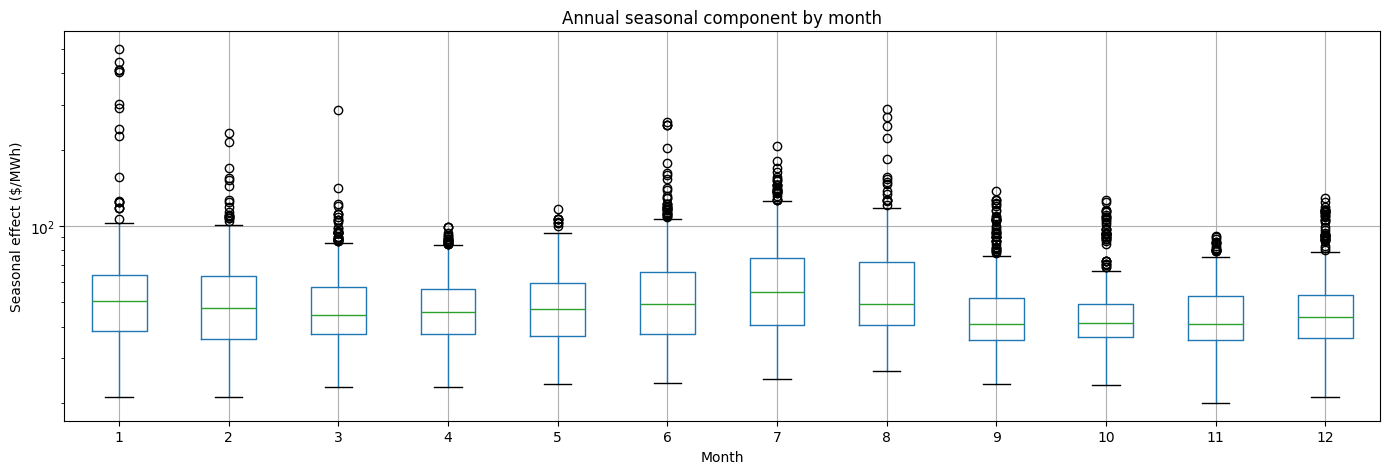

In [33]:
# Add a month column
df_ice_electric_prices['month'] = df_ice_electric_prices.index.month

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
df_ice_electric_prices.boxplot(column='wtd_avg_price_mwh', by='month', ax=ax)

ax.set_title('Annual seasonal component by month')
ax.set_xlabel('Month')
ax.set_ylabel('Seasonal effect ($/MWh)')
ax.set_yscale("log")
plt.suptitle('')  # removes the default pandas boxplot title
plt.tight_layout()

In [ ]:
# Monthly seasonality: box plots of price by calendar month

In [ ]:
# Day-of-week seasonality: box plots of price by day of week

In [ ]:
# STL or classical decomposition into trend / seasonal / residual

In [ ]:
# ACF / PACF plots

In [ ]:
# Distribution: histogram, QQ-plot, summary statistics (mean, median, std, skew, kurtosis, min, max)

In [ ]:
# Stationarity test (ADF and/or KPSS) on levels and first differences

---
## 3 · Univariate Analysis — Consumption Series

**Question:** What are the dominant trend, seasonal patterns (annual, monthly, weekly, hour-of-day), and distributional characteristics of the hourly consumption series? Is consumption growing or declining over the sample period, and how strong are the within-week and within-day cycles?

**Exit criterion:** Trend direction and approximate magnitude are documented; seasonal strength is quantified at annual, monthly, weekly, and daily frequencies; distributional shape is characterised; stationarity is assessed. The analyst can state whether consumption needs differencing or transformation before use as a regressor.

In [ ]:
# Full time-series plot of hourly consumption (consider daily/weekly resampling for visibility)

In [ ]:
# Annual trend: rolling annual mean overlaid on resampled series

In [ ]:
# Monthly seasonality: box plots of consumption by calendar month

In [ ]:
# Day-of-week seasonality: box plots of consumption by day of week

In [ ]:
# Hour-of-day seasonality: average load profile (mean +/- 1 std by hour)

In [ ]:
# STL decomposition on daily-aggregated consumption

In [ ]:
# ACF / PACF plots

In [ ]:
# Distribution: histogram, QQ-plot, summary statistics

In [ ]:
# Stationarity test (ADF and/or KPSS) on daily-aggregated series

---
## 4 · Relationship Between Price and Consumption

**Question:** Do price and consumption co-move, and at what temporal frequency is the relationship strongest? Is consumption a useful leading or coincident predictor of price, or is the relationship weak enough to exclude it from the model?

**Exit criterion:** A cross-correlation function (CCF) at the daily frequency is plotted and the peak lag is identified. The contemporaneous correlation is reported at daily, weekly, and monthly aggregations. Any asymmetry (price spikes during high-consumption periods) is noted. The analyst makes a go/no-go recommendation on including consumption as an exogenous regressor.

In [ ]:
# Align series to a common daily index

In [ ]:
# Dual-axis time-series overlay: price and daily consumption

In [ ]:
# Scatter plots at daily, weekly, and monthly aggregations with Pearson and Spearman correlations

In [ ]:
# Cross-correlation function (CCF): price vs lagged consumption, +/- 30 days

In [ ]:
# Conditional distributions: price distribution split by consumption quartile

---
## 5 · Anomaly Detection

**Question:** Which observations in each series are outliers or represent data gaps, and what is the appropriate treatment — imputation, removal, or flagging — for each case?

**Exit criterion:** All outliers above a defined threshold (e.g. IQR fence or z-score cutoff) are listed with dates and values. All gaps longer than 1 period are catalogued. A treatment decision (impute / winsorise / drop / flag) is recorded for every identified issue. The cleaned series lengths are confirmed before proceeding.

In [ ]:
# Price series: flag values beyond 3 IQR fences; plot with outliers highlighted

In [ ]:
# Price series: identify and catalogue date gaps (missing calendar days)

In [ ]:
# Consumption series: flag values beyond 3 IQR fences; plot with outliers highlighted

In [ ]:
# Consumption series: identify gaps and zero/implausibly-low readings

In [ ]:
# Document treatment decisions in a summary table; apply and confirm cleaned series lengths

---
## 6 · Feature Engineering Candidates

**Question:** Which calendar and derived features are motivated by the patterns observed above, and which can be ruled out as uninformative before modelling?

**Exit criterion:** A prioritised list of feature candidates is produced, each linked to a specific finding from sections 2–5. Features are grouped by type (calendar dummies, trigonometric encodings, lag/rolling-window features, exogenous regressors). Any feature that showed no signal in the EDA is explicitly excluded with a stated reason.

In [ ]:
# Calendar features motivated by seasonality analysis: month, day-of-week, week-of-year, quarter

In [ ]:
# Trigonometric encodings for cyclic features (sin/cos transforms)

In [ ]:
# Lag and rolling-window features motivated by ACF/PACF analysis

In [ ]:
# Holiday / peak-demand event flags if anomaly analysis identified recurring spike dates

In [ ]:
# Exogenous regressor candidates from section 4 (consumption aggregates, if signal confirmed)

---
## 7 · Summary and Modelling Decisions

Complete this cell after all sections above are finished. Summarise the key findings and record the decisions they motivate for `02_modelling.ipynb`.

### Key findings

| # | Finding | Section |
|---|---------|--------|
| 1 | | |
| 2 | | |
| 3 | | |

### Modelling decisions

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Forecast target (levels / log / diff) | | |
| Forecast horizon | 12 months ahead | CFO budgeting requirement |
| Minimum history required | | |
| Seasonal periods to model explicitly | | |
| Include consumption as exogenous regressor | | |
| Anomaly treatment applied to training data | | |
| Feature set entering the model | | |